In [6]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. Trigger the Upload Button
print("Upload your 'Telco_customer_churn.xlsx' file below:")
uploaded = files.upload()

# Get the name of the file you just uploaded
file_name = list(uploaded.keys())[0]

# 2. Load the data
df = pd.read_excel(file_name)
print(f"Successfully loaded: {file_name}")

# 3. Data Cleaning: Fix 'Total Charges' (converts spaces to 0)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# 4. Feature Selection
features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
            'Tenure Months', 'Phone Service', 'Multiple Lines',
            'Internet Service', 'Contract', 'Paperless Billing',
            'Monthly Charges', 'Total Charges']

X = df[features].copy()
y = df['Churn Value']

# 5. Label Encoding for text columns
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# 6. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 8. Results
y_pred = model.predict(X_test_scaled)
print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Upload your 'Telco_customer_churn.xlsx' file below:


Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx
Successfully loaded: Telco_customer_churn.xlsx

--- Model Performance ---
Accuracy: 79.77%

Detailed Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1009
           1       0.67      0.56      0.61       400

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.79      0.80      0.79      1409



Text(0.5, 1.0, '**Top Drivers of Customer Churn**')

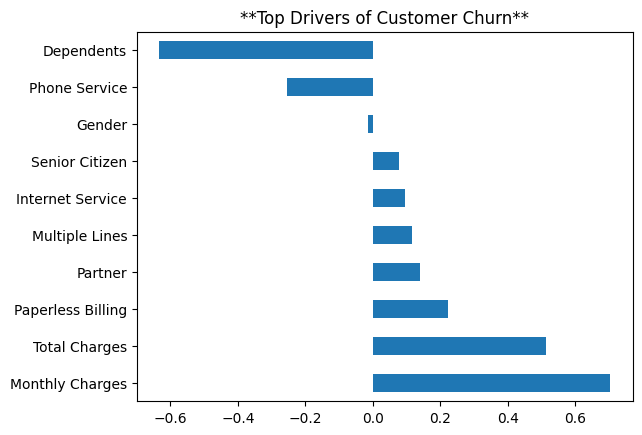

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Get coefficients
weights = pd.Series(model.coef_[0], index=X.columns)
weights.sort_values(ascending=False)[:10].plot(kind='barh')
plt.title("**Top Drivers of Customer Churn**")

**Cross-Validation Accuracy (5-folds):** 74.67%


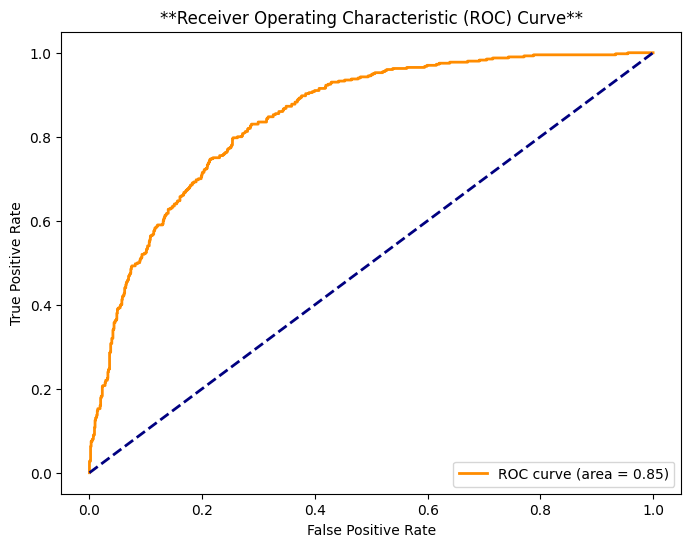

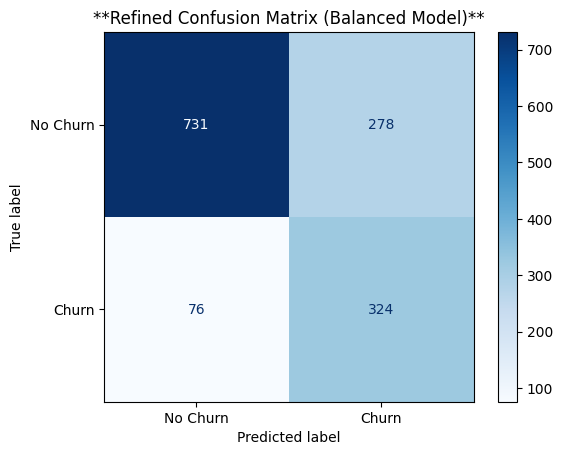


**Top 5 Business Insights (Odds Ratios):**
- Monthly Charges: Increases churn odds by 2.00x
- Total Charges: Increases churn odds by 1.65x
- Paperless Billing: Increases churn odds by 1.23x
- Partner: Increases churn odds by 1.14x
- Multiple Lines: Increases churn odds by 1.10x


In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Balanced Logistic Regression (Class Imbalance handle karne ke liye)
# Purane model ko touch nahi kar rahe, bas ek improved version check kar rahe hain
balanced_model = LogisticRegression(class_weight='balanced', max_iter=1000)
balanced_model.fit(X_train_scaled, y_train)

# 2. K-Fold Cross Validation (Check consistency)
cv_scores = cross_val_score(balanced_model, X_train_scaled, y_train, cv=5)
print(f"**Cross-Validation Accuracy (5-folds):** {cv_scores.mean():.2%}")

# 3. ROC-AUC Curve (Industry Standard Metric)
y_pred_prob = balanced_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('**Receiver Operating Characteristic (ROC) Curve**')
plt.legend(loc="lower right")
plt.show()

# 4. Professional Confusion Matrix Heatmap
y_pred_balanced = balanced_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('**Refined Confusion Matrix (Balanced Model)**')
plt.show()

# 5. Extracting "Odds Ratios" for LinkedIn Insights
import numpy as np
feature_names = X.columns
coeffs = balanced_model.coef_[0]
odds_ratios = np.exp(coeffs)
sorted_idx = np.argsort(odds_ratios)[-5:] # Top 5 predictors

print("\n**Top 5 Business Insights (Odds Ratios):**")
for i in sorted_idx[::-1]:
    print(f"- {feature_names[i]}: Increases churn odds by {odds_ratios[i]:.2f}x")